<a href="https://colab.research.google.com/github/PavaniMaganti/telecom-customer-churn-prediction/blob/main/Customer_Churn_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction Using Machine Learning

## Objective

Customer churn is one of the most critical challenges faced by subscription-based businesses. Retaining existing customers is often more cost-effective than acquiring new ones.

The objective of this project is to analyze customer behavior, identify factors contributing to churn, and build machine learning models capable of predicting whether a customer is likely to leave the company.

The project includes data cleaning, exploratory data analysis, feature engineering, model building, model evaluation, and business recommendations.

In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [52]:
df = pd.read_csv("telco.csv")

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [53]:
df["Offer"].value_counts(dropna=False)

,count
Offer,
NaN,3877
Offer B,824
Offer E,805
Offer D,602
Offer A,520
Offer C,415


In [54]:
df["Internet Type"].value_counts(dropna=False)

,count
Internet Type,
Fiber Optic,3035
DSL,1652
NaN,1526
Cable,830


In [55]:
pd.crosstab(
    df["Internet Service"],
    df["Internet Type"],
    dropna=False
)

Internet Type,Cable,DSL,Fiber Optic,NaN
Internet Service,,,,
No,0,0,0,1526
Yes,830,1652,3035,0


In [56]:
df.duplicated().sum()

np.int64(0)

### Duplicate Analysis

No duplicate records were identified in the dataset. Therefore, no duplicate removal was required prior to analysis.

In [57]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [58]:
(df["Churn Label"].value_counts(normalize=True) * 100).round(2)

,proportion
Churn Label,
No,73.46
Yes,26.54


### Dataset Summary

The dataset contains 7,043 customer records and 50 features describing customer demographics, services, billing information, satisfaction levels, and churn behavior.

No duplicate records were identified.

The target variable (Churn Label) indicates whether a customer has left the company.

Customer churn distribution:

- Churned Customers: 1,869 (26.54%)
- Retained Customers: 5,174 (73.46%)

The dataset exhibits moderate class imbalance but remains suitable for predictive modelling.

In [59]:
df[["Offer", "Internet Type"]].isnull().sum()

,0
Offer,3877
Internet Type,1526


In [60]:
df["Offer"] = df["Offer"].fillna("No Offer")

df["Internet Type"] = df["Internet Type"].fillna("No Internet")

In [61]:
df[["Offer", "Internet Type"]].isnull().sum()

,0
Offer,0
Internet Type,0


### Missing Value Treatment

Two columns contained missing values:

- Offer
- Internet Type

Business investigation revealed that missing Offer values likely represented customers who did not receive a marketing offer.

Similarly, missing Internet Type values corresponded to customers without internet service.

To preserve business information and avoid unnecessary record removal, missing values were replaced with meaningful categories:

- Offer → "No Offer"
- Internet Type → "No Internet"

In [62]:
df[[
    "Customer Status",
    "Churn Label",
    "Churn Category",
    "Churn Reason",
    "Churn Score"
]].head()

,Customer Status,Churn Label,Churn Category,Churn Reason,Churn Score
0,Churned,Yes,Competitor,Competitor offered more data,91
1,Churned,Yes,Competitor,Competitor made better offer,69
2,Churned,Yes,Competitor,Competitor made better offer,81
3,Churned,Yes,Dissatisfaction,Limited range of services,88
4,Churned,Yes,Price,Extra data charges,67


In [63]:
drop_columns = [
    "Customer ID",
    "Customer Status",
    "Churn Category",
    "Churn Reason",
    "Churn Score"
]

df = df.drop(columns=drop_columns)

df.shape

(7043, 45)

### Feature Selection and Data Leakage Prevention

The original dataset contained 50 columns. Five columns were removed before analysis and modelling because they either uniquely identified customers or contained information that directly revealed churn outcomes, which could lead to data leakage and unrealistic model performance.

Removed Columns:
- Customer ID
- Customer Status
- Churn Category
- Churn Reason
- Churn Score

After removal, the dataset contained 45 features suitable for exploratory analysis and predictive modelling.

# Exploratory Data Analysis (EDA)

EDA 1: Churn Distribution

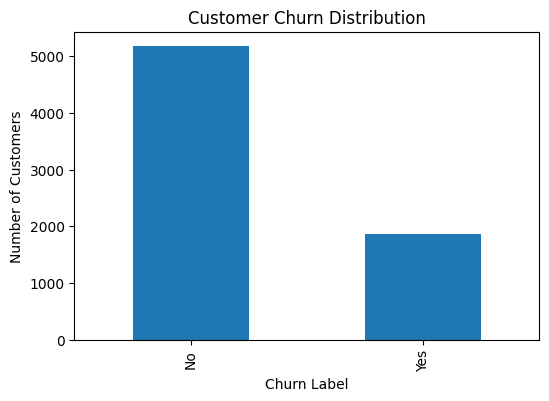

In [64]:
churn_counts = df["Churn Label"].value_counts()

churn_counts.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
plt.show()

EDA 2: Contract vs Churn

In [65]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


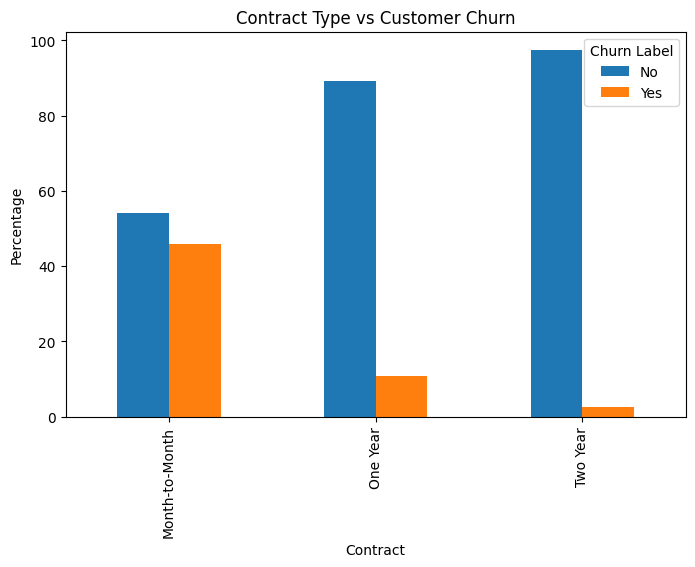

In [106]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Contract Type vs Customer Churn")
plt.ylabel("Percentage")
plt.show()

EDA 3: Satisfaction Score vs Churn

In [66]:
pd.crosstab(
    df["Satisfaction Score"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Satisfaction Score,,
1,0.000000,100.000000
2,0.000000,100.000000
3,83.902439,16.097561
4,100.000000,0.000000
5,100.000000,0.000000


In [67]:
tenure_churn = df.groupby("Churn Label")["Tenure in Months"].mean()
tenure_churn

,Tenure in Months
Churn Label,
No,37.591225
Yes,17.979133


In [68]:
salary_churn = pd.crosstab(
    pd.cut(df["Monthly Charge"], bins=4),
    df["Churn Label"],
    normalize="index"
) * 100

salary_churn

Churn Label,No,Yes
Monthly Charge,,
"(18.15, 43.375]",87.677725,12.322275
"(43.375, 68.5]",78.503994,21.496006
"(68.5, 93.625]",63.187773,36.812227
"(93.625, 118.75]",66.418416,33.581584


In [69]:
internet_churn = pd.crosstab(
    df["Internet Type"],
    df["Churn Label"],
    normalize="index"
) * 100

internet_churn

Churn Label,No,Yes
Internet Type,,
Cable,74.337349,25.662651
DSL,81.416465,18.583535
Fiber Optic,59.275124,40.724876
No Internet,92.595020,7.404980


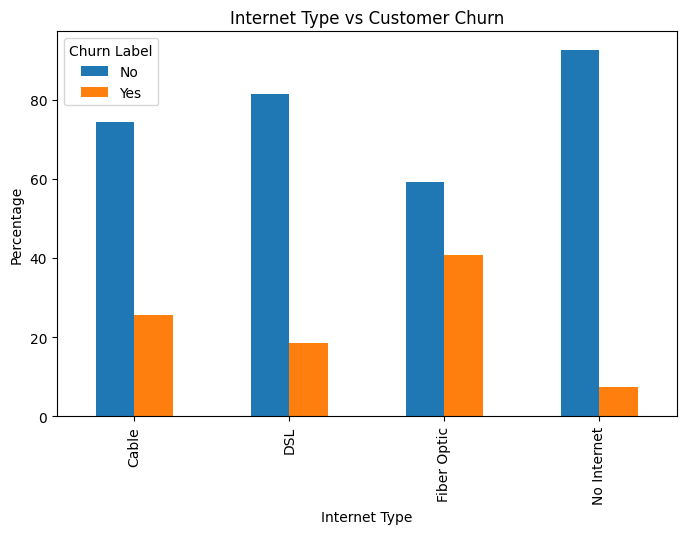

In [107]:
internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Internet Type vs Customer Churn")
plt.ylabel("Percentage")
plt.show()

### Key EDA Findings

- Approximately 26.54% of customers churned, meaning nearly 1 in 4 customers left the company.
- Customers on month-to-month contracts showed the highest churn rate (45.84%), while two-year contracts had the lowest churn rate (2.55%).
- Lower customer satisfaction was strongly associated with higher churn.
- Churned customers had an average tenure of 18 months compared to 38 months for retained customers, indicating that newer customers are more likely to leave.
- Customers with higher monthly charges exhibited significantly higher churn rates than lower-paying customers.
- Fiber Optic customers showed the highest churn rate (40.72%), while customers without internet service had the lowest churn rate (7.40%).
- Contract type, customer satisfaction, tenure, monthly charges, and internet type emerged as the strongest churn drivers.

# **Feature Engineering**

In [77]:
df.dtypes.value_counts()

,count
object,24
int64,10
float64,8


In [79]:
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

In [80]:
X = df.drop("Churn Label", axis=1)

y = df["Churn Label"]

print(X.shape)
print(y.shape)

(7043, 41)
(7043,)


In [81]:
X = pd.get_dummies(X, drop_first=True)

X.shape

(7043, 48)

**Step 1: Train-Test Split**

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 48)
(1409, 48)
(5634,)
(1409,)


**Step 2: Feature Scaling**

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Step 3: First Model — Logistic Regression**

In [84]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

**Step 4: Evaluation**

In [85]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9638041163946061
              precision    recall  f1-score   support

          No       0.97      0.99      0.98      1035
         Yes       0.96      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



**Step 5: Second Model — Random forest**

In [86]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [87]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9531582682753726
              precision    recall  f1-score   support

          No       0.95      0.99      0.97      1035
         Yes       0.97      0.85      0.91       374

    accuracy                           0.95      1409
   macro avg       0.96      0.92      0.94      1409
weighted avg       0.95      0.95      0.95      1409



In [88]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
16,Satisfaction Score,0.441192
7,Tenure in Months,0.046302
15,Total Revenue,0.040605
6,Number of Referrals,0.036172
10,Monthly Charge,0.032776
44,Contract_Two Year,0.030729
11,Total Charges,0.030298
14,Total Long Distance Charges,0.022899
0,Age,0.020702
33,Internet Type_Fiber Optic,0.019847


In [89]:
!pip install xgboost

In [91]:
y = y.replace({
    "No": 0,
    "Yes": 1
})

y_train = y_train.replace({
    "No": 0,
    "Yes": 1
})

y_test = y_test.replace({
    "No": 0,
    "Yes": 1
})

/tmp/ipykernel_5356/572014321.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({
/tmp/ipykernel_5356/572014321.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({
/tmp/ipykernel_5356/572014321.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_te

In [92]:
print(y_train.unique())
print(y_test.unique())

[0 1]
[0 1]


In [93]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [94]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9623846699787083
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1035
           1       0.95      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



### Model Evaluation

Three machine learning models were evaluated to compare their ability to predict customer churn.

- Logistic Regression was selected as a baseline model because it is simple, interpretable, and effective for binary classification.
- Random Forest was used to identify complex patterns in customer behaviour and determine feature importance.
- XGBoost was used because it is a powerful boosting algorithm known for achieving high predictive performance.

#### Results

- Logistic Regression achieved the highest accuracy (96.38%).
- XGBoost achieved a similar accuracy (96.24%).
- Random Forest achieved an accuracy of 95.32%.
- Logistic Regression was selected as the final model due to its strong performance and simplicity.

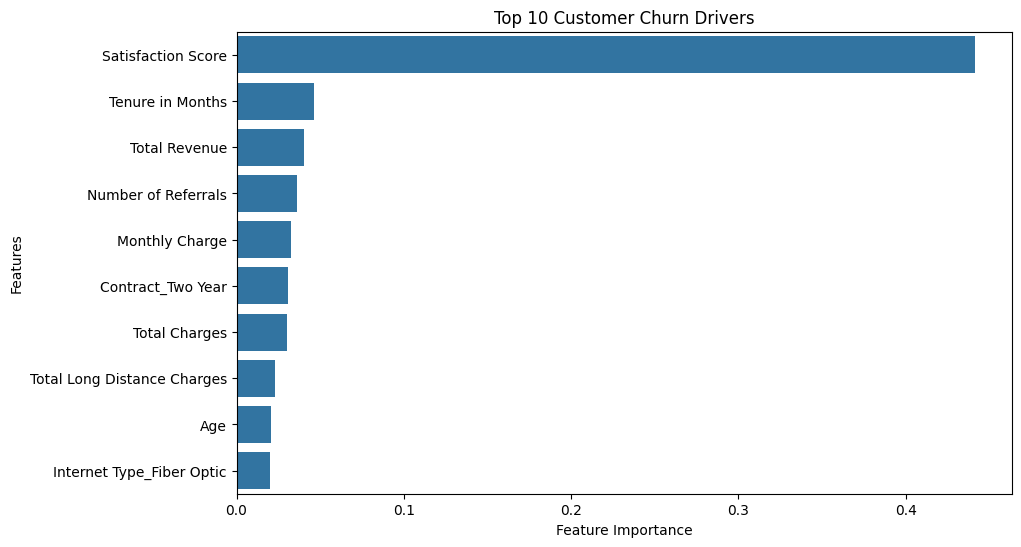

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Customer Churn Drivers")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

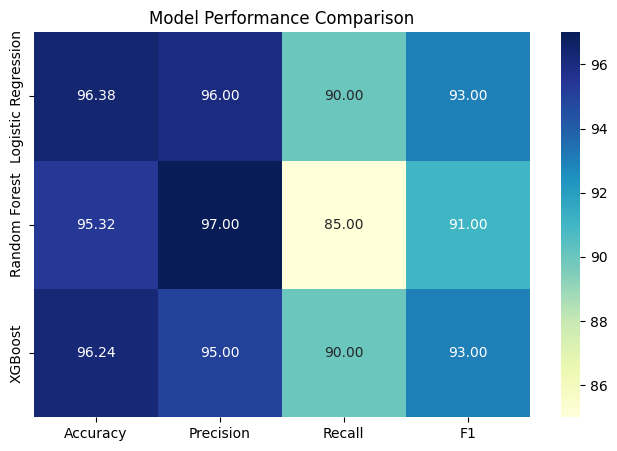

In [96]:
metrics = pd.DataFrame({
    "Accuracy":[96.38,95.32,96.24],
    "Precision":[96,97,95],
    "Recall":[90,85,90],
    "F1":[93,91,93]
},
index=["Logistic Regression","Random Forest","XGBoost"])

plt.figure(figsize=(8,5))
sns.heatmap(
    metrics,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Model Performance Comparison")
plt.show()

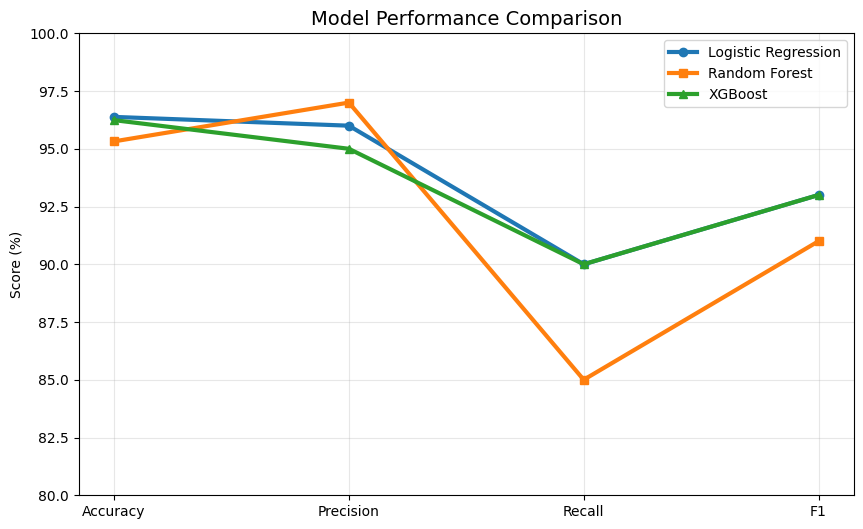

In [99]:
metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Logistic Regression": [96.38, 96, 90, 93],
    "Random Forest": [95.32, 97, 85, 91],
    "XGBoost": [96.24, 95, 90, 93]
})

plt.figure(figsize=(10,6))

plt.plot(metrics["Metric"], metrics["Logistic Regression"],
         marker="o", linewidth=3, label="Logistic Regression")

plt.plot(metrics["Metric"], metrics["Random Forest"],
         marker="s", linewidth=3, label="Random Forest")

plt.plot(metrics["Metric"], metrics["XGBoost"],
         marker="^", linewidth=3, label="XGBoost")

plt.title("Model Performance Comparison", fontsize=14)
plt.ylabel("Score (%)")
plt.ylim(80,100)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

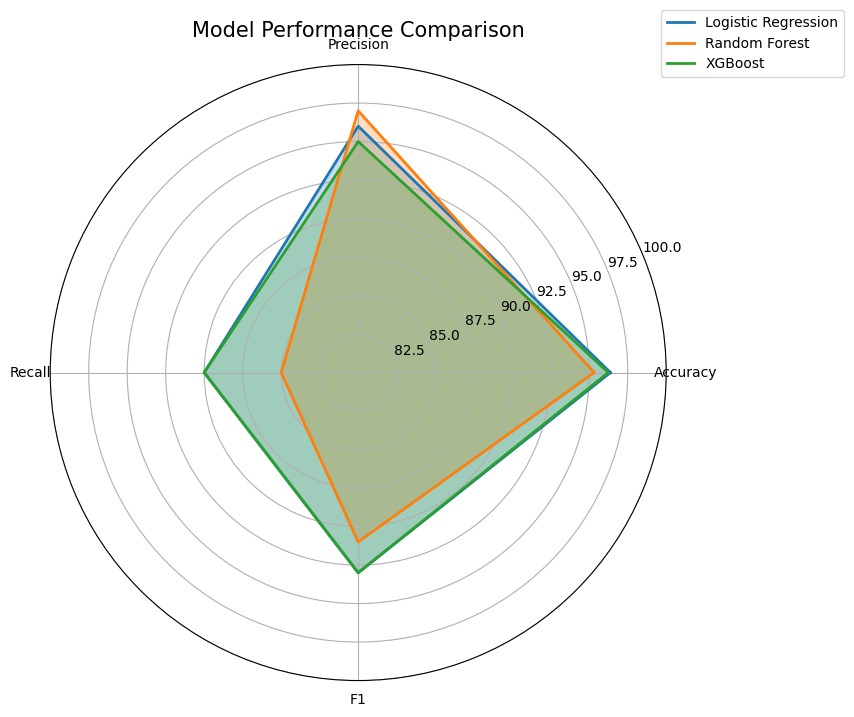

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Model metrics
categories = ['Accuracy', 'Precision', 'Recall', 'F1']

lr = [96.38, 96, 90, 93]
rf = [95.32, 97, 85, 91]
xgb = [96.24, 95, 90, 93]

# Radar chart setup
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Close the circle
lr += lr[:1]
rf += rf[:1]
xgb += xgb[:1]

angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, lr, linewidth=2, label='Logistic Regression')
ax.fill(angles, lr, alpha=0.25)

ax.plot(angles, rf, linewidth=2, label='Random Forest')
ax.fill(angles, rf, alpha=0.25)

ax.plot(angles, xgb, linewidth=2, label='XGBoost')
ax.fill(angles, xgb, alpha=0.25)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

ax.set_ylim(80, 100)

plt.title("Model Performance Comparison", size=15, pad=20)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

In [103]:
y_pred_lr_numeric = pd.Series(y_pred_lr).replace({
    "No": 0,
    "Yes": 1
})

/tmp/ipykernel_5356/2168400618.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_pred_lr_numeric = pd.Series(y_pred_lr).replace({


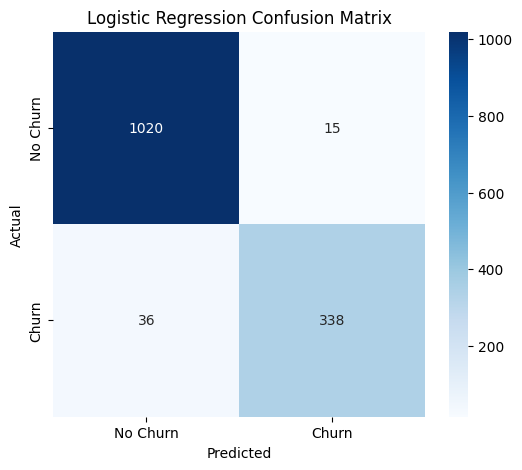

In [104]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr_numeric)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Business Recommendations

Based on the analysis and machine learning results:

- Improve customer satisfaction, as it was identified as the strongest predictor of churn.
- Focus retention efforts on newer customers, who showed significantly higher churn rates.
- Encourage customers to move from month-to-month contracts to longer-term contracts.
- Review pricing strategies for customers with high monthly charges.
- Investigate the high churn rate among Fiber Optic customers and address potential service or pricing concerns.
- Develop targeted retention campaigns for customers identified as high-risk by the predictive model.

### Conclusion

This project analyzed customer churn using exploratory data analysis and machine learning techniques.

The analysis identified customer satisfaction, tenure, monthly charges, contract type, and internet type as the key factors influencing customer churn.

Three machine learning models were evaluated, with Logistic Regression achieving the best overall performance (96.38% accuracy). The model can help organizations identify customers at risk of leaving and support proactive retention strategies.

The findings demonstrate how data-driven insights can improve customer retention and reduce revenue loss.

### Future Improvements

- Experiment with additional machine learning models and hyperparameter tuning.
- Incorporate customer interaction and support history data.
- Deploy the model as an interactive web application using Streamlit.
- Develop a real-time churn prediction dashboard for business users.